# pymesh2D: Mesh Generation from GEBCO Bathymetry

[![GitHub](https://img.shields.io/badge/GitHub-pymesh2d-blue?logo=github)](https://github.com/GeoOcean/pymesh2d)

This notebook demonstrates how to use **pymesh2D** to generate unstructured triangular meshes from bathymetric data. 
`pymesh2D` is a Python-based mesh generator for two-dimensional polygonal geometries, providing Delaunay-based triangulation algorithms.

**Repository:** [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)

---

## Table of Contents

1. [Data Loading](#1-loading-gebco-bathymetric-data)
2. [Coastline Extraction](#2-coastline-polygon-extraction)
3. [Polygon Preprocessing](#3-polygon-resampling-and-preparation)
4. [Mesh Generation](#4-mesh-generation-with-delaunay-refinement)
5. [Mesh Quality Optimization](#5-mesh-smoothing-and-quality-control)
6. [Bathymetry Interpolation](#6-bathymetry-interpolation)
7. [Export](#7-export-to-grid-formats)

---

## 1. Loading GEBCO Bathymetric Data

We start by loading bathymetric data from the **GEBCO 2025** dataset, which provides global elevation data including ocean bathymetry.

The data is accessed directly from the CEDA archive via OPeNDAP protocol.

In [38]:
import xarray as xr

# Target mesh resolution in meters (raster resolution)
raster_resolution = 300

# Load GEBCO 2025 data from remote server
GEBCO = xr.open_dataset(
    "https://dap.ceda.ac.uk/thredds/dodsC/bodc/gebco/global/gebco_2025/ice_surface_elevation/netcdf/GEBCO_2025.nc"
)

# Define bounding box for the region of interest (Morocco/Southern Spain)
bbox = {"lon_min": -6.75, "lon_max": -3, "lat_min": 33, "lat_max": 38}

# Extract the region of interest
GEBCO_sel = GEBCO.sel(
    lon=slice(bbox["lon_min"], bbox["lon_max"]),
    lat=slice(bbox["lat_min"], bbox["lat_max"]),
)

GEBCO_sel

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 1200, lon: 900)
Coordinates:
  * lat        (lat) float64 10kB 33.0 33.01 33.01 33.01 ... 37.99 37.99 38.0
  * lon        (lon) float64 7kB -6.748 -6.744 -6.74 ... -3.01 -3.006 -3.002
Data variables:
    crs        |S64 64B ...
    elevation  (lat, lon) int16 2MB ...
Attributes: (12/37)
    title:                           The GEBCO_2025 Grid - a continuous terra...
    summary:                         The GEBCO_2025 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    references:                      DOI: 10.5285/37c52e96-24ea-67ce-e063-708...
    node_offset:                     1.0
    DODS.strlen:                     0

### Visualize the Bathymetry

Let's plot the elevation data using a terrain colormap:

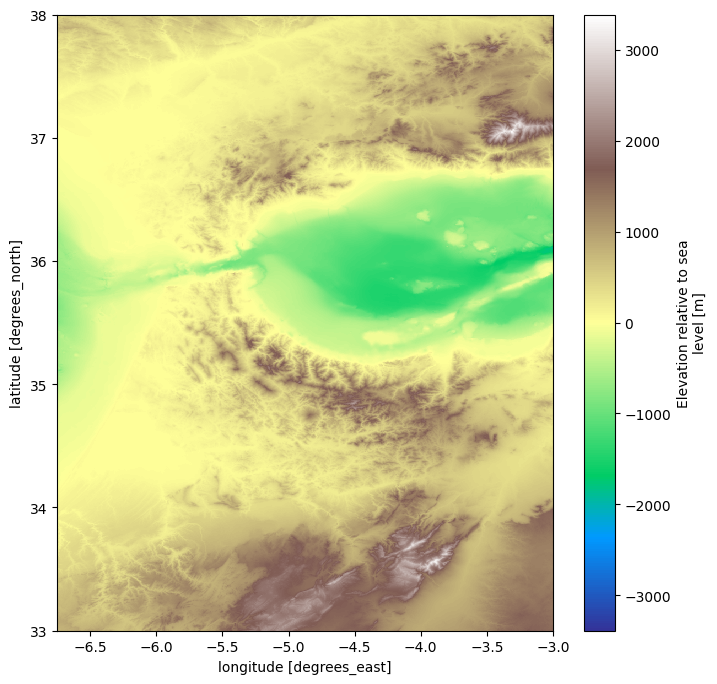

In [39]:
GEBCO_sel["elevation"].plot(cmap="terrain", figsize=(8, 8));

---

## 2. Coastline Polygon Extraction

Now we extract the coastline by identifying the **zero-elevation contour** (sea level). 
The `getiso_polygone` function extracts polygons where elevation ≤ 0 (i.e., the ocean areas).

In [40]:
import pyproj

# Get the CRS from the dataset
crs_var = GEBCO_sel["crs"]
epsg = crs_var.attrs.get("epsg_code", None)
code = int(epsg.split(":")[-1])
crs = pyproj.CRS.from_epsg(code)

In [41]:
from pymesh2d.geom_util.getiso import getiso_polygone

lon = GEBCO_sel["lon"]
lat = GEBCO_sel["lat"]
zdat = GEBCO_sel["elevation"]

# Extract ocean polygon (elevation <= 0)
polygone_intersection = getiso_polygone(lon, lat, zdat, zmax=0.0)

### Visualize the Extracted Coastline

Overlay the extracted polygon on the bathymetry:

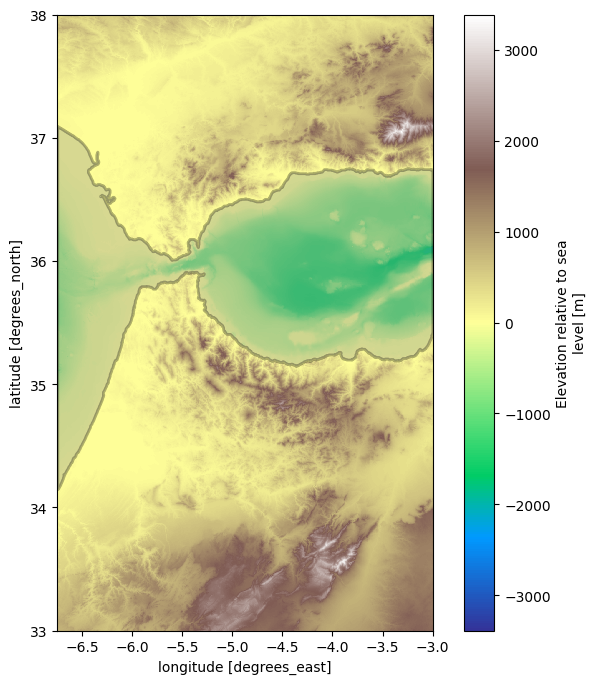

In [42]:
import geopandas as gpd

raster = GEBCO_sel["elevation"].plot(cmap="terrain", figsize=(8, 8))
ax = raster.axes
gdf = gpd.GeoDataFrame(geometry=[polygone_intersection], crs=crs)
gdf.plot(ax=ax, facecolor="grey", alpha=0.3, edgecolor="black", linewidth=2);

---

## 3. Polygon Resampling and Preparation

Before mesh generation, we need to:
1. **Reproject** the polygon to UTM coordinates (for accurate distance calculations)
2. **Resample** the polygon vertices to achieve uniform spacing matching our target resolution

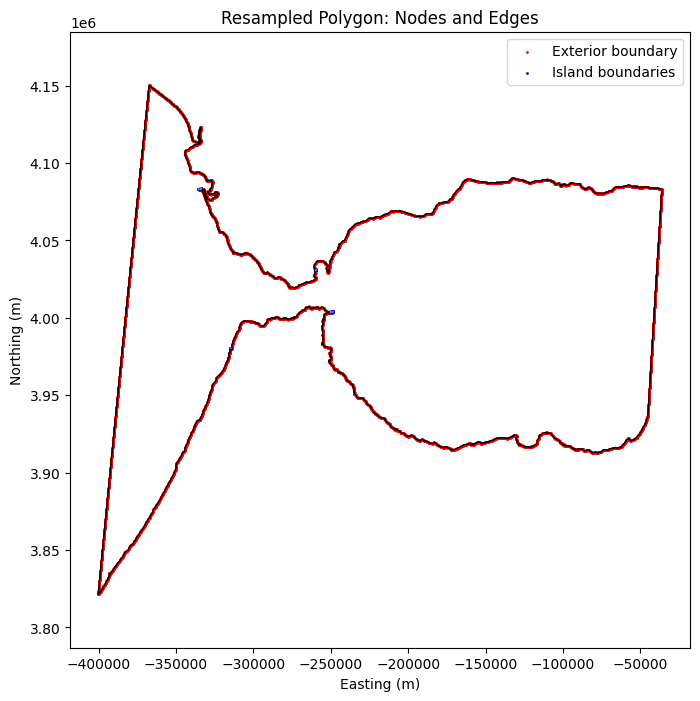

In [43]:
import matplotlib.pyplot as plt

from pymesh2d.geom_util.poly_util import resample_polygon
from pymesh2d.geom_util.proj_util import get_utm_crs_from_crs, reproject_geometry

# Reproject to UTM for metric calculations
polygone_intersection_UTM = reproject_geometry(
    polygone_intersection, crs, get_utm_crs_from_crs(crs)
)

# Resample polygon vertices to target resolution
polygone_intersection_resampled_UTM = resample_polygon(
    polygone_intersection_UTM, raster_resolution
)

# Visualize the resampled polygon
fig, ax = plt.subplots(figsize=(8, 8))

x, y = polygone_intersection_resampled_UTM.exterior.xy
ax.scatter(x, y, color="red", s=1, label="Exterior boundary")
ax.plot(x, y, color="black", lw=1)

for i, hole in enumerate(polygone_intersection_resampled_UTM.interiors):
    xh, yh = hole.xy
    label = "Island boundaries" if i == 0 else None
    ax.scatter(xh, yh, color="blue", s=1, label=label)
    ax.plot(xh, yh, color="gray", linestyle="--", lw=1)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Resampled Polygon: Nodes and Edges")
ax.axis("equal")
ax.legend();

### Create Bounding Box and Final Domain

We create a bounding box polygon and intersect it with the coastline to define our final mesh domain:

In [44]:
from shapely.geometry import Polygon
from pymesh2d.geom_util.poly_util import buffer_area

# Create bounding box polygon
poly_bbox = Polygon([
    (bbox["lon_min"], bbox["lat_min"]),
    (bbox["lon_min"], bbox["lat_max"]),
    (bbox["lon_max"], bbox["lat_max"]),
    (bbox["lon_max"], bbox["lat_min"]),
    (bbox["lon_min"], bbox["lat_min"]),
])

# Reproject to UTM and apply small negative buffer
poly_bbox_UTM = reproject_geometry(poly_bbox, crs, get_utm_crs_from_crs(crs))
poly_bbox_UTM = buffer_area(poly_bbox_UTM, -0.05)

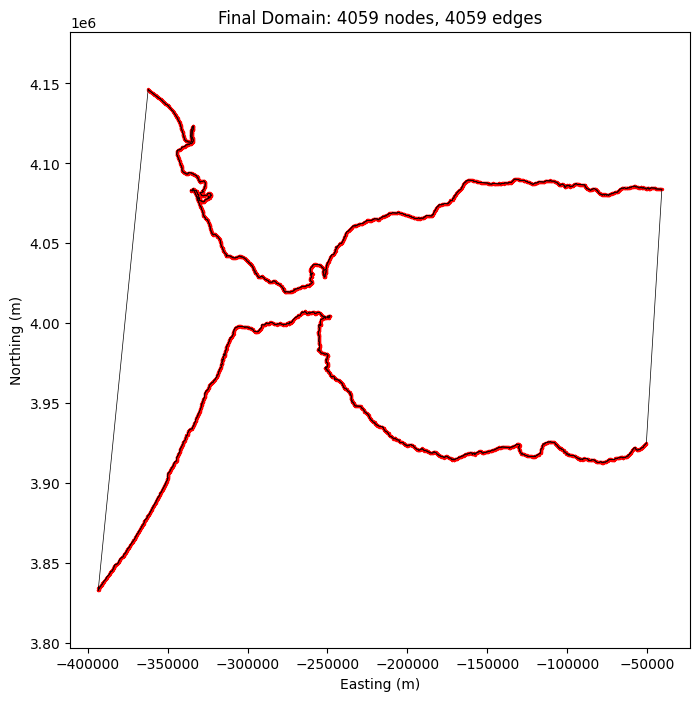

In [45]:
from pymesh2d.geom_util.poly_util import polygon_to_node_edge

# Compute intersection to get final domain
polygone_final_UTM = polygone_intersection_resampled_UTM.intersection(poly_bbox_UTM)
node, edge = polygon_to_node_edge(polygone_final_UTM)

# Visualize the final domain
fig, ax = plt.subplots(figsize=(8, 8))

for e in edge.astype(int):
    ax.plot(node[e, 0], node[e, 1], "k-", lw=0.5)
ax.scatter(node[:, 0], node[:, 1], color="red", s=2)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Final Domain: {len(node)} nodes, {len(edge)} edges")
ax.axis("equal");

---

## 4. Mesh Generation with Delaunay Refinement

Now we generate the mesh using **Delaunay refinement**. We also define a **mesh sizing function** (`hfun`) based on wave dispersion characteristics, which controls element sizes based on local water depth.

In [46]:
from pymesh2d.geomesh_util.depth_field import depth_field_from_xr
from pymesh2d.geomesh_util.hfun_dispercion import hfun_wavenumhunt

# Create depth field for mesh sizing function
depth_field = depth_field_from_xr(
    GEBCO_sel, 
    input_crs=crs, 
    output_crs=get_utm_crs_from_crs(crs), 
    var_name="elevation"
)

# Define mesh sizing function based on wave dispersion
def hfun(test):
    """Mesh sizing function based on wave characteristics.
    
    Uses the Hunt approximation for wave number to determine
    appropriate element sizes based on water depth.
    """
    return hfun_wavenumhunt(
        test, 
        depth_field, 
        T=60 * 60 * 3,  # Wave period (3 hours)
        N=10,           # Elements per wavelength
        zmin=1,         # Minimum depth
        hmin=raster_resolution  # Minimum element size
    )

In [47]:
from pymesh2d.refine import refine
from pymesh2d.smooth import smooth

# Mesh refinement options
opts = {"kind": "delaunay"}

# Generate initial mesh with Delaunay refinement
vert_UTM, etri, tria, tnum = refine(node, edge, [], opts, hfun)

# Smooth the mesh for better quality
vert_UTM, etri, tria, tnum = smooth(vert_UTM, etri, tria, tnum)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
         10               4089               4066
         12               4091               4066
         20               4129               9983
         30               4165              22435
         40               4168              23202
         45               4170              23216


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0               9322              23182
          4               7750              22812
          8               1830              22816
         12                 42              22814
         16                  5              22814



---

## 5. Mesh Smoothing and Quality Control

After refinement, we analyze mesh quality by computing **circumcenters** and identifying potentially problematic small flow links.

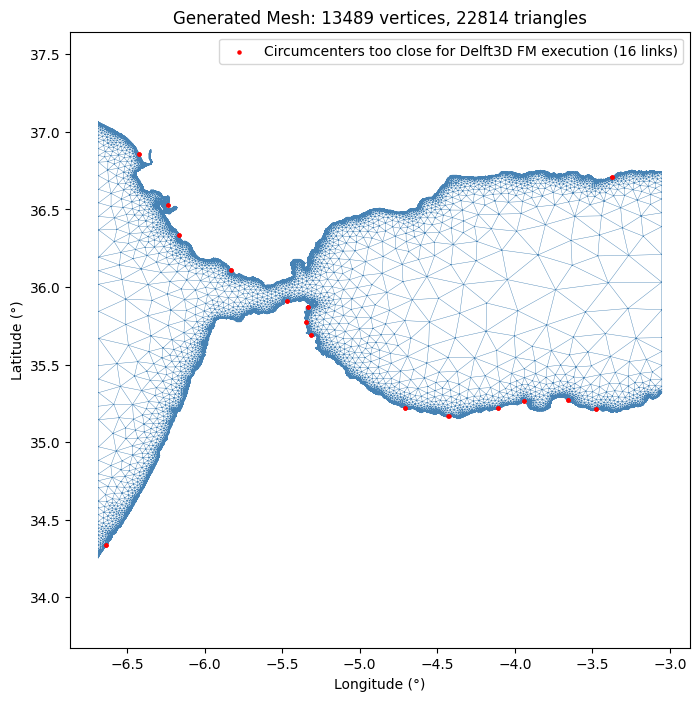

In [56]:
from pymesh2d.geom_util.proj_util import reproject_node
from pymesh2d.mesh_util.tricon import tricon
from pymesh2d.mesh_util.circo import small_flow_centers

# Compute triangle connectivity
edge_cc, _ = tricon(tria, None)

# Find circumcenters and identify small flow links
circumcenters_UTM, nlinktoosmall = small_flow_centers(
    vert_UTM, tria, edge_cc, 
    removesmalllinkstrsh=0.11, 
    conn=None
)

# Reproject back to geographic coordinates
vert = reproject_node(vert_UTM, get_utm_crs_from_crs(crs), crs)
circumcenters = reproject_node(circumcenters_UTM, get_utm_crs_from_crs(crs), crs)

# Visualize the mesh
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(vert[:, 0], vert[:, 1], tria[:, 0:3], color="steelblue", lw=0.3)

if nlinktoosmall > 0:
    ax.scatter(circumcenters[:, 0], circumcenters[:, 1], 
               color="red", s=5, zorder=5,
               label=f"Circumcenters too close for Delft3D FM execution ({nlinktoosmall} links)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Generated Mesh: {len(vert)} vertices, {len(tria)} triangles")
ax.axis("equal")
ax.legend();

### Circumcenter Distance Control for Delft3D FM

For numerical models like **Delft3D FM**, it is essential to control the distance between circumcenters of adjacent triangles. 
Small flow links (i.e., circumcenters that are too close together) can cause numerical instabilities in the hydrodynamic computations.

The `removesmalllinkstrsh` parameter in the smoothing step allows automatic detection and correction of these problematic elements:

In [49]:
# Alternative approach: combine refinement and smoothing with options
opts_refine = {"kind": "delaunay"}
opts_smooth = {"removesmalllinkstrsh": 0.11}

vert_UTM_c, etri_c, tria_c, tnum_c = refine(node, edge, [], opts_refine, hfun)
vert_UTM_c, etri_c, tria_c, tnum_c = smooth(vert_UTM_c, etri_c, tria_c, tnum_c, opts_smooth)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
         10               4089               4066
         12               4091               4066
         20               4129               9983
         30               4165              22435
         40               4168              23202
         45               4170              23216


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0               9322              23184
          4               7734              22812
          8               1804              22808
         12                 36              22806
         16                  8              22806
         20                 19              22816



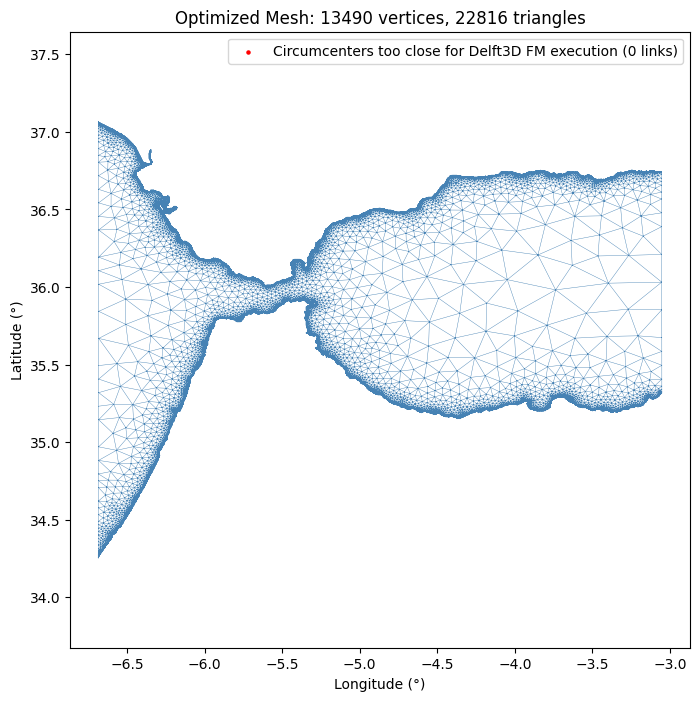

In [57]:
# Analyze the optimized mesh
edge_c, _ = tricon(tria_c, None)

circumcenters_UTM_c, nlinktoosmall_c = small_flow_centers(
    vert_UTM_c, tria_c, edge_c, 
    removesmalllinkstrsh=0.11, 
    conn=None
)

vert_c = reproject_node(vert_UTM_c, get_utm_crs_from_crs(crs), crs)
circumcenters_c = reproject_node(circumcenters_UTM_c, get_utm_crs_from_crs(crs), crs)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(vert_c[:, 0], vert_c[:, 1], tria_c[:, 0:3], color="steelblue", lw=0.3)

ax.scatter(circumcenters_c[:, 0], circumcenters_c[:, 1], 
            color="red", s=5, zorder=5,
            label=f"Circumcenters too close for Delft3D FM execution ({nlinktoosmall_c} links)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Optimized Mesh: {len(vert_c)} vertices, {len(tria_c)} triangles")
ax.axis("equal")
ax.legend();

---

## 6. Bathymetry Interpolation

Interpolate the elevation values from the GEBCO raster onto the mesh vertices:

In [51]:
from pymesh2d.geomesh_util.interpolation_mesh import interpolate_from_xr

# Interpolate bathymetry onto mesh vertices
z = interpolate_from_xr(GEBCO_sel, vert, var_name="elevation")

---

## 7. Export to Grid Formats

Finally, we export the mesh to various formats. Here we use:
- **NetCDF** format (ADCIRC-style 2DM for D-Flow FM)
- **GRD** format with boundary conditions

In [52]:
import numpy as np
from pymesh2d.geomesh_util.grd_util import adcirc2DFlowFM

# Export to NetCDF format
adcirc2DFlowFM(np.column_stack((vert, z)), tria, "GEBCO_grid.nc")

### Identify Boundary Conditions

Classify mesh boundaries as open (ocean) or land based on depth:

In [53]:
from pymesh2d.geomesh_util.border_util import identify_boundary

# Identify boundary types (open ocean vs land)
edge_tag, edge_open, edge_land = identify_boundary(vert, tria, z, zlim=15)

In [54]:
from pymesh2d.geomesh_util.grd_util import export_to_grd

# Export to GRD format with boundaries
export_to_grd(
    "GEBCO_grid.grd",
    vert=vert,
    tria=tria,
    z=z,
    crs=crs,
    edge_tag=edge_tag,
    edge_open=edge_open,
    edge_land=edge_land,
)

### Visualize Final Grid with Boundaries

Display the final mesh with boundary classification:

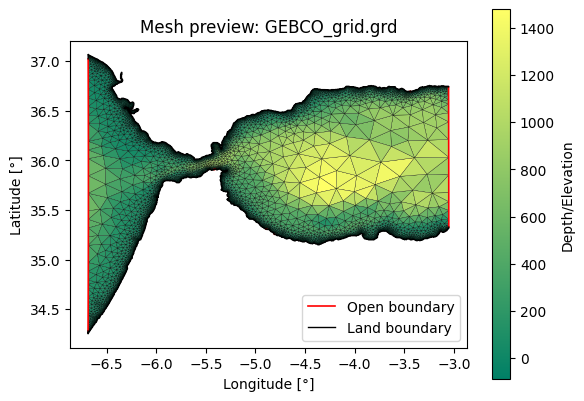

In [55]:
from pymesh2d.geomesh_util.grd_util import plot_grd

plot_grd("GEBCO_grid.grd", show_boundaries=True)

---

### References

- **pymesh2D Repository**: [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)
- **Original MESH2D**: Darren Engwirda, *Locally-optimal Delaunay-refinement and optimisation-based mesh generation*, Ph.D. Thesis, University of Sydney, 2014 - [https://github.com/dengwirda/mesh2d](https://github.com/dengwirda/mesh2d)
- **GEBCO**: General Bathymetric Chart of the Oceans - [https://www.gebco.net/](https://www.gebco.net/)